# Packed (scale/offset) NetCDF files

Files whose variables are stored as int16 with `scale_factor`/`add_offset`. pyramids unpacks transparently on read; note the dtype/scale columns in the variable table below.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile

import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon

from pyramids.netcdf import NetCDF, UgridDataset
from pyramids.feature import FeatureCollection
from cleopatra.reference import add_features

DATA = Path('../../../../examples/data/netcdf/samples')

2026-06-22 01:30:15 | INFO | pyramids.base.config | Logging is configured.


## `cf__20v__1d3-3d17.nc`

ECMWF surface fields: 17 packed int16 variables sharing one (time, lat, lon) grid. Longitudes run 0–360.

**Open the file and inspect the container**

In [2]:
nc = NetCDF.read_file(DATA / 'cf__20v__1d3-3d17.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\cf__20v__1d3-3d17.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [3]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (3):
    latitude             size=73
    longitude            size=144
    time                 size=12
  Variables (20):
    blh dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='m' scale=0.10873938334451697 offset=3570.143670551653
    cp dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='m' scale=4.82483645945993e-07 offset=0.01580857665942046
    e dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='m of water' scale=1.1670245190791643e-07 offset=-0.0023219971296410792
    hcc dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='(0 - 1)' scale=1.5259720441921504e-05 offset=0.49998474028055817
    latitude dims=('/latitude',) shape=(73,) dtype=float32 unit='degrees_north'
    lcc dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='(0 - 1)' scale=1.5259720441921504e-05 offset=0.49998

**Global attributes**

In [4]:
nc.global_attributes

{'Conventions': 'CF-1.0',
 'history': '2004-09-15 17:04:29 GMT by mars2netcdf-0.92'}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

2026-06-22 01:30:16 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-22 01:30:16 | WARNING | pyramids.base.config.gdal | GDAL[1] Clamping output bounds to (-19898358.979298,-18546349.318789) -> (19898358.979298, 20037508.342789)


<Axes: >

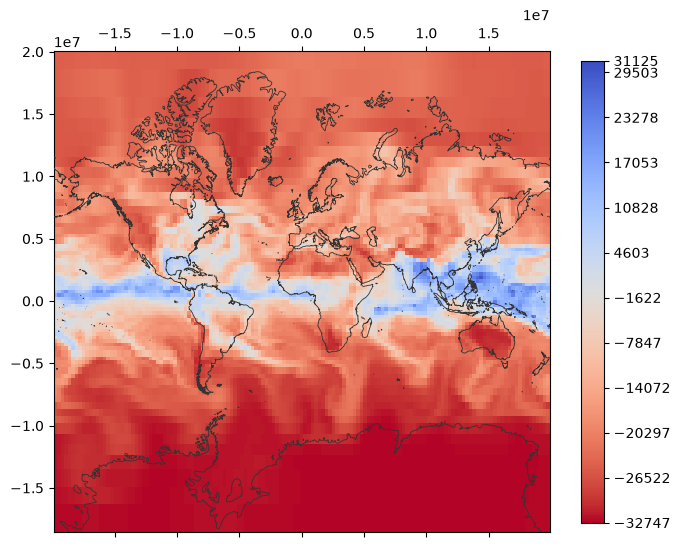

In [5]:
# select the variable to plot
field = nc.get_variable('tcw')
# this grid's longitudes run 0..360; wrap them to -180..180 to match the basemap
field = field.wrap_longitude()
# clip to +-85 latitude: Web Mercator is only valid to ~85 deg, past which the poles stretch huge
field = field.crop(bbox=(-179.0, -85.0, 179.0, 85.0))
# reproject to Web Mercator (EPSG:3857), the coordinate system the basemap tiles use
field = field.to_crs(3857)
# draw the field over an OpenStreetMap basemap
glyph = field.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
add_features(glyph.ax, "coastline", "50m", crs=3857, zorder=5)

**Wrap longitude to −180–180** — this grid spans 0–360 (Pacific-centred). `wrap_longitude` re-frames it to the −180–180 (Greenwich-centred) convention; we wrap the selected variable, then plot the re-centred map.

2026-06-22 01:30:17 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-22 01:30:17 | WARNING | pyramids.base.config.gdal | GDAL[1] Clamping output bounds to (-19898358.979298,-18546349.318789) -> (19898358.979298, 20037508.342789)


<Axes: >

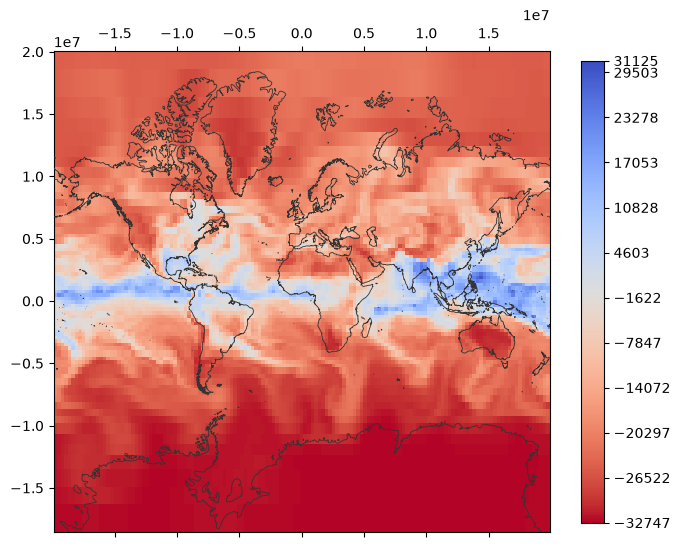

In [6]:
# select the variable to plot
field = nc.get_variable('tcw')
# this grid's longitudes run 0..360; wrap them to -180..180 to match the basemap
field = field.wrap_longitude()
# clip to +-85 latitude: Web Mercator is only valid to ~85 deg, past which the poles stretch huge
field = field.crop(bbox=(-179.0, -85.0, 179.0, 85.0))
# reproject to Web Mercator (EPSG:3857), the coordinate system the basemap tiles use
field = field.to_crs(3857)
# draw the field over an OpenStreetMap basemap
glyph = field.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
add_features(glyph.ax, "coastline", "50m", crs=3857, zorder=5)

**Retrieve the underlying data**

In [7]:
var = nc.get_variable('tcw')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (12, 73, 144)
min / mean / max: -32767.0 -24796.70115106545 32767.0


**Reduce a dimension** — collapse the time axis to its mean

In [8]:
time_mean = nc.reduce('time', how='mean')
print('dimensions after reducing time:', dict(time_mean.dimension_sizes))

dimensions after reducing time: {'x': 144, 'y': 73}


**Add a variable** — derive a 2-D field and append it as a new variable

In [9]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=var.geotransform, epsg=var.epsg or 4326,
    variable_name='tcw_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'tcw_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['blh', 'cp', 'e', 'hcc', 'lcc', 'lsp', 'mcc', 'msl', 'p10u', 'p10v', 'p2d', 'p2t', 'tcc', 'tco3', 'tcw', 'tcw_slice0', 'tcwv', 'tp']


**Remove a variable**

In [10]:
nc.remove_variable('tcw_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['blh', 'cp', 'e', 'hcc', 'lcc', 'lsp', 'mcc', 'msl', 'p10u', 'p10v', 'p2d', 'p2t', 'tcc', 'tco3', 'tcw', 'tcwv', 'tp']


**Crop with a real-world polygon** — values are stored int16-packed, but `crop` operates on the georeferenced grid all the same. We crop to **South America**. Web Mercator basemaps span −180…180 while this grid is 0–360, so we `wrap_longitude()` the variable and reproject it to Web Mercator (EPSG:3857) — then it lines up with the **OpenStreetMap basemap** (`basemap=True`, fetched over the network). The whole-container crop that follows runs in the file's native 0–360 coordinates (no basemap).

2026-06-22 01:30:18 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


cropped tcw bounds: [np.float64(-81.2), np.float64(-38.8), np.float64(-46.2), np.float64(11.2)]


<Axes: >

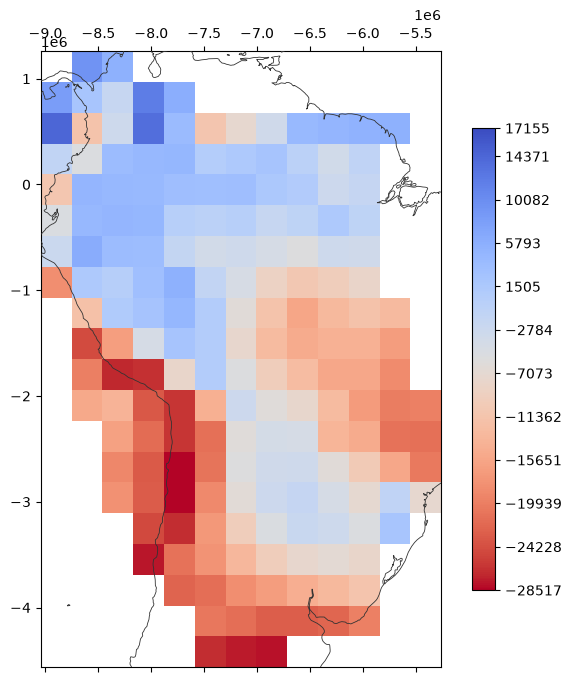

In [11]:
# South America, in -180..180 longitudes
region = [
    (-81, 9), (-75, 11), (-65, 5), (-50, 5), (-51, -5), (-45, -23),
    (-55, -35), (-66, -40), (-73, -30), (-78, -18), (-81, -5), (-81, 9),
]
aoi = FeatureCollection(gpd.GeoDataFrame(geometry=[Polygon(region)], crs=4326))

# select the variable
tcw = nc.get_variable('tcw')
# this grid is 0..360; wrap to -180..180 to match the polygon
tcw = tcw.wrap_longitude()
# crop to the South America polygon
tcw_sa = tcw.crop(aoi)
print('cropped tcw bounds:', [round(b, 1) for b in tcw_sa.total_bounds])
# reproject to Web Mercator and plot over the basemap
tcw_sa_3857 = tcw_sa.to_crs(3857)
glyph = tcw_sa_3857.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
add_features(glyph.ax, "coastline", "50m", crs=3857, zorder=5)

**Crop the whole container** — clip every variable with the same polygon.

2026-06-22 01:30:18 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-22 01:30:18 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-22 01:30:18 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-22 01:30:18 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-22 01:30:18 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


...

2026-06-22 01:30:19 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-22 01:30:20 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-22 01:30:20 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


variables in cropped container: ['blh', 'cp', 'e', 'hcc', 'lcc', 'lsp', 'mcc', 'msl', 'p10u', 'p10v', 'p2d', 'p2t', 'tcc', 'tco3', 'tcw', 'tcwv', 'tp']


<Axes: >

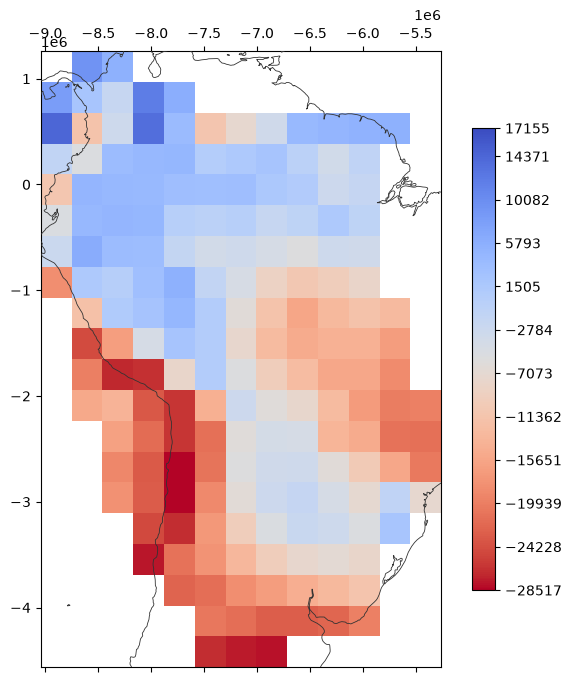

In [12]:
# whole-container crop in the file's native 0-360 longitudes (shift the polygon by +360)
native_region = [(x + 360 if x < 0 else x, y) for x, y in region]
aoi_native = FeatureCollection(gpd.GeoDataFrame(geometry=[Polygon(native_region)], crs=4326))
cropped = nc.crop(aoi_native)
print('variables in cropped container:', cropped.variable_names)
# show the cropped tcw over the basemap: reuse the reprojected result from the previous cell
tcw_sa_3857 = tcw_sa.to_crs(3857)
glyph = tcw_sa_3857.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
add_features(glyph.ax, "coastline", "50m", crs=3857, zorder=5)

**Save the result to a new NetCDF file**

In [13]:
out = work / 'cropped.nc'
cropped.to_file(str(out))
print('saved cropped container to', out.name, '->', out.exists())

saved cropped container to cropped.nc -> True
